# Corner case: bipolar grid fold

Challenging regions include those that cross periodic boundaries or OM4's Arctic **bipolar fold** — the tripolar grid's northern edge, which folds onto itself. `regionate` drives all grid logic from the grid's own topology, so a region straddling the fold is traced into a **single** boundary loop with the fold treated as *interior* rather than as a wall. This relies on xgcm's north-fold boundary: the grid loader builds the grid with `boundary={"X": "periodic", "Y": {"fold": "corner"}}`.

In [1]:
# Import packages
import numpy as np
import xgcm
import xarray as xr
import sectionate
import regionate
import matplotlib.pyplot as plt

## 0. Load data

In [2]:
from load_example_model_grid import load_MOM6_zint_heat_budget
grid = load_MOM6_zint_heat_budget(fold=True)
ds = grid._ds

File 'MOM6_global_example_vertically_integrated_heat_budget_v0_0_6.nc' already exists at ../data/MOM6_global_example_vertically_integrated_heat_budget_v0_0_6.nc. Skipping download.


The model archives the advective heat-flux components `T_adx`, `T_ady` and the cell areas `areacello` in **single precision** (float32). Our cross-boundary integral sums thousands of these fluxes with partial cancellation, so float32 rounding (relative precision $\sim 10^{-7}$) limits the budget closure to $\sim 10^{-5}$. Since the discrete divergence theorem is *exact* in real arithmetic (it closes to round-off in regionate's float64 unit tests), we promote these fields to float64 before integrating. This isolates the exact grid-conforming boundary math from the precision of the stored diagnostics, so the boundary/volume comparison below closes to round-off rather than to the single-precision floor.

In [3]:
# Promote the single-precision (float32) advective fluxes and cell areas to float64 so
# the boundary/volume budget closes to round-off rather than the ~1e-5 float32 floor.
for var in ["T_adx", "T_ady", "areacello"]:
    ds[var] = ds[var].astype("float64")

We want to must verify that the diagnosed advective heat tendencies (flux convergence) are column-wise consistent with the convergence computed offline from fluxes on the cell faces.

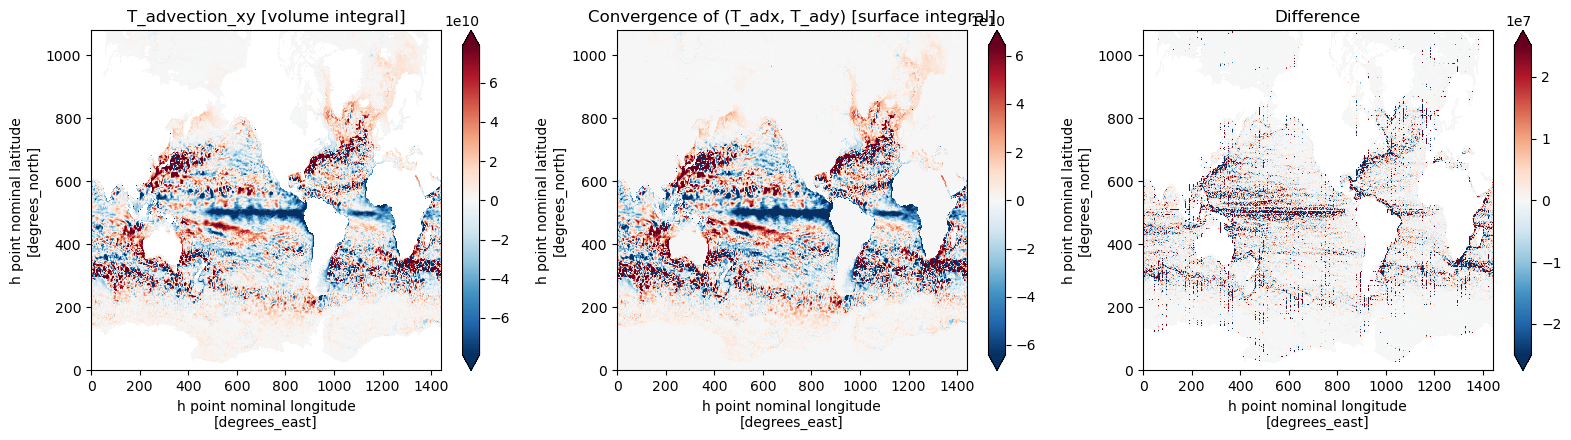

In [4]:
dheatdt_dynamics = (ds['T_advection_xy']*ds['areacello']).sum('z_l')
dheatdt_dynamics = dheatdt_dynamics.where(dheatdt_dynamics!=0.)

plt.figure(figsize=(16, 4.5))
plt.subplot(1,3,1)
dheatdt_dynamics.plot(robust=True)
plt.title("T_advection_xy [volume integral]")

T_adv_heating = -(grid.diff(ds['T_adx'].sum("z_l"), "X") + grid.diff(ds['T_ady'].sum("z_l"), "Y"))
plt.subplot(1,3,2)
T_adv_heating.plot(robust=True)
plt.title("Convergence of (T_adx, T_ady) [surface integral]")

plt.subplot(1,3,3)
(dheatdt_dynamics-T_adv_heating).plot(robust=True)
plt.title("Difference");
plt.tight_layout()

These relative errors are on the order of 10$^{-5}$, which is consistent with the single precision format of the outputs.

## 1. Determine a mask for the region of interest.

Let us consider the heat budget for the coldest regions of the high arctic (excluding the Southern Ocean), which have an annual-mean temperature that is below the freezing point of 0ºC (for freshwater at surface air pressure).

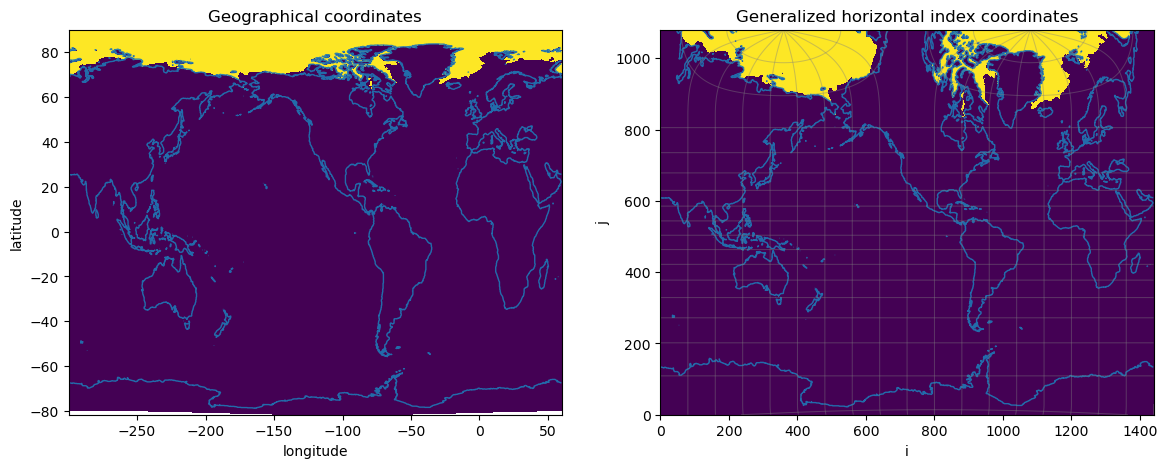

In [5]:
ds['mask'] = (
    (ds['tos'].squeeze() < 0.) &
    (ds['geolat'] > 0)
)
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
plt.pcolor(
    ds.geolon_c,
    ds.geolat_c,
    ds.mask,
    vmin=0.2, vmax=1.
)
plt.contour(
    ds.geolon,
    ds.geolat,
    ds.deptho,
    levels=[0.],
    colors="C0",
    linewidths=1.,
    alpha=0.9
)
plt.title("Geographical coordinates")
plt.xlabel("longitude")
plt.ylabel("latitude")

plt.subplot(1,2,2)
plt.pcolor(
    ds.mask
)
plt.contour(
    ds.deptho,
    levels=[0.],
    colors="C0",
    linewidths=1.,
    alpha=0.9
)
dlon=20.
plt.contour(
    ds['geolon_c'],
    colors="grey",
    linestyles="solid",
    linewidths=0.75,
    alpha=0.4,
    levels=np.arange(-300., 60.+dlon, dlon)
)

dlat = 10.
plt.contour(
    ds['geolat_c'],
    colors="grey",
    linestyles="solid",
    linewidths=0.75,
    alpha=0.4,
    levels=np.arange(-90., 90.+dlat, dlat)
);
plt.title("Generalized horizontal index coordinates")
plt.xlabel("i")
plt.ylabel("j");

## 2. We use `regionate` to find the sections that bound the region

On the backend, this uses `contourpy` to find the decimal indices of the contours of the mask in index space, and then converts these into the corresponding integer indices of the ocean model's vorticity grid (corners of C-grid tracer cells). Because the grid carries a north-fold boundary, contour segments lying on the fold seam between two in-mask cells are recognized as *interior* and dropped, and the two sides of the fold are stitched into a single closed loop by their coincidence at the seam.

In [6]:
from regionate import MaskRegions
region_dict = MaskRegions(ds.mask, grid).region_dict

We plot both the indices and geographical coordinates to verify that these points indeed *exactly* bound the mask.

**Note:** The high-Arctic cold region straddles the tripolar grid's bipolar fold. Because the grid is built with a north-fold boundary, `regionate` traces it as a **single** region: the fold seam is *interior* to the region, so no boundary faces lie along it and there is nothing to cancel. (Were the fold instead treated as a wall — `Y="extend"` — the same region would split into two halves joined only across the fold, whose fold-normal fluxes are equal and opposite and cancel when summed — giving the right total for the wrong reason.)


The high-Arctic region is now a single region that spans the bipolar fold, rather than
splitting into two halves. The mask also contains 127 other regions --
separate cold water bodies, external islands, and internal holes -- which this method
carefully accounts for as well.


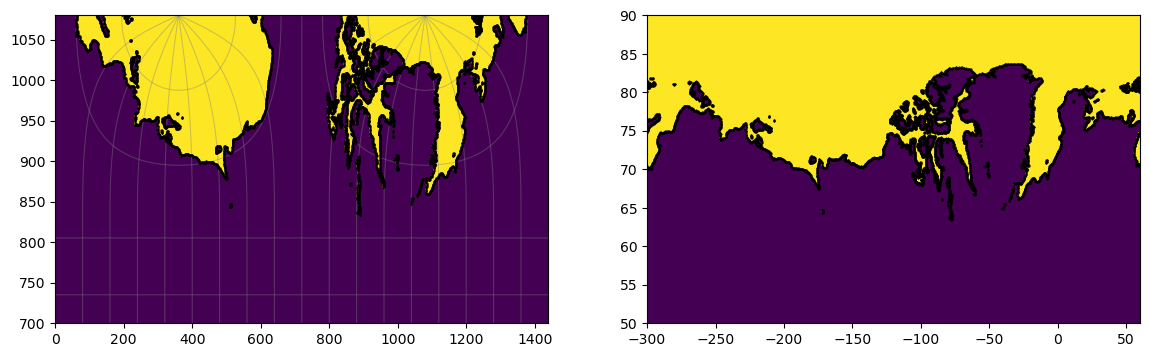

In [7]:
plt.figure(figsize=(14, 4))
plt.subplot(1,2,1)
plt.pcolor(
    region_dict[0].mask,
)
dlon=20.
plt.contour(
    ds['geolon_c'],
    colors="grey",
    linestyles="solid",
    linewidths=0.75,
    alpha=0.4,
    levels=np.arange(-300., 60.+dlon, dlon)
)

dlat = 10.
plt.contour(
    ds['geolat_c'],
    colors="grey",
    linestyles="solid",
    linewidths=0.75,
    alpha=0.4,
    levels=np.arange(-90., 90.+dlat, dlat)
);

plt.ylim(700, None)
for p, region in enumerate(region_dict.values()):
    plt.plot(region.i_c, region.j_c, "k.", markersize=1)
    
plt.subplot(1,2,2)
plt.pcolor(
    ds.geolon_c,
    ds.geolat_c,
    region_dict[0].mask,
)
plt.ylim(50, None)
for p, region in enumerate(region_dict.values()):
    plt.plot(region.lons_c, region.lats_c, "k.", markersize=1)

print(f"""
The high-Arctic region is now a single region that spans the bipolar fold, rather than
splitting into two halves. The mask also contains {len(region_dict)-1} other regions --
separate cold water bodies, external islands, and internal holes -- which this method
carefully accounts for as well.""")

## 3. We use `sectionate` to compute the advective heat fluxes that converge into the region.

In [8]:
total_convergent_heat_transport = 0.

for p, region in enumerate(region_dict.values()):
    ds_sec = sectionate.convergent_transport(
        grid,
        region.i_c,
        region.j_c,
        utr="T_adx",
        vtr="T_ady",
        layer="z_l",
        interface="z_i",
        outname="conv_heat_transport",
        positive_in=region.mask,
    )
    
    region.convergent_heat_transport = ds_sec['conv_heat_transport'].sum("z_l").isel(time=0).compute()
    
    total_convergent_heat_transport += region.convergent_heat_transport.sum(["sect"]).values


In [9]:
print(f"The total advective heat convergence into these cold regions of the Arctic is: {total_convergent_heat_transport*1e-12} TW")

The total advective heat convergence into these cold regions of the Arctic is: 38.724284716604 TW


## 4. We verify our calculation obeys the discrete divergence theorem

A grid-consistent boundary must satisfy the **discrete divergence theorem**: the net advective heat transport across the region's boundary equals the heat-flux convergence summed over the region's cells. We compute that interior convergence by differencing the *same* advective fluxes `T_adx`, `T_ady` (now float64), so the comparison closes to round-off — isolating the exact grid-conforming boundary math from the single-precision floor of the stored diagnostics.

(The model's own independently-diagnosed advective tendency `T_advection_xy` agrees with this flux convergence to $\sim 10^{-5}$, i.e. to single precision, as verified globally near the top of this notebook.)

In [10]:
# Interior heat-flux convergence, differenced from the SAME (float64) advective fluxes the
# boundary integral uses -- so the discrete divergence theorem closes to round-off. On this
# symmetric ('outer') grid a plain scalar divergence is exact (no U<->V rotation), and the
# northernmost cells' seam flux is read directly from the stored T_ady row.
advective_heating_rate = float(
    (-(grid.diff(ds['T_adx'].sum('z_l'), 'X') + grid.diff(ds['T_ady'].sum('z_l'), 'Y')))
    .isel(time=0).where(region_dict[0].mask).sum(['xh', 'yh']).values
)

In [11]:
residual = total_convergent_heat_transport - advective_heating_rate
percent_error = np.abs(residual / advective_heating_rate) * 100
print(f"""
The total advective heat flux converging across the region's boundary is {total_convergent_heat_transport*1e-12:.6f} TW,
matching the {advective_heating_rate*1e-12:.6f} TW convergence integrated over the region's cells
to within {percent_error:.2e}% (residual {residual*1e-12:.2e} TW) -- i.e. to round-off, confirming
the traced boundary is exactly grid-consistent with the interior flux convergence.
""")


The total advective heat flux converging across the region's boundary is 38.724285 TW,
matching the 38.724285 TW convergence integrated over the region's cells
to within 0.00e+00% (residual 0.00e+00 TW) -- i.e. to round-off, confirming
the traced boundary is exactly grid-consistent with the interior flux convergence.



## 5. The pay-off: understanding advective tendencies by tracing them back to boundary fluxes

Where this flexible convergent-flux-integral approach becomes powerful is when we unravel the cross-boundary integral to reveal the spatial (and temporal) pattern of the heat fluxes into the region. This is a particularly powerful tool for oceanographic problems, where very strong anisotropies due to bathymetric variations, surface forcings, and emergent dynamical structures (boundary currents, jets, eddies, etc.) cause fluxes to vary several orders of magnitude and are often dominated by a few localized hot spots.

Below, we visualize the spatial structure of the heat fluxes into the biggest of the sub-regions.

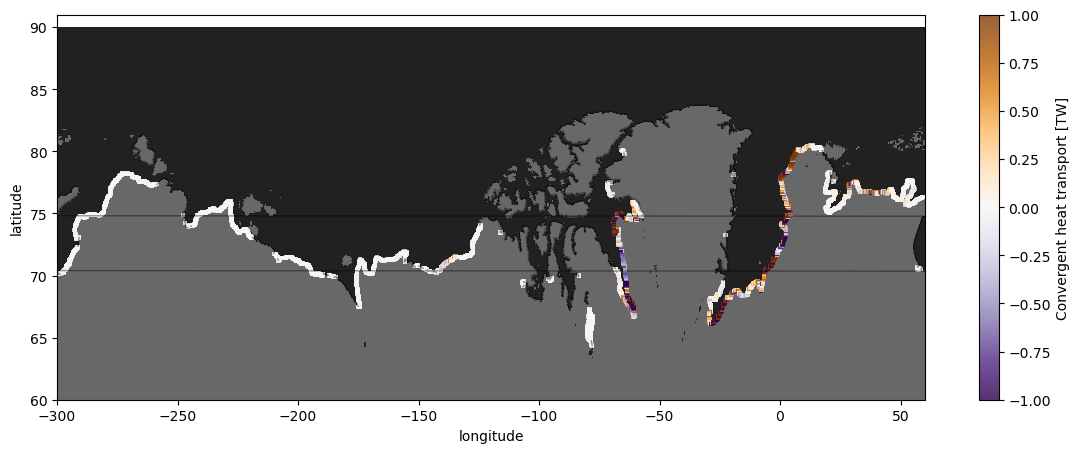

In [12]:
vmax = 1
plt.figure(figsize=(14,5))

plt.pcolor(
    ds.geolon_c,
    ds.geolat_c,
    region_dict[0].mask,
    cmap="Greys",
    vmin=-3, vmax=1.5
)

for p, region in enumerate(region_dict.values()):
    if len(region.lons_c) < 100: continue
    plt.plot(
        region.convergent_heat_transport['lon'].where(region.convergent_heat_transport==0.),
        region.convergent_heat_transport['lat'].where(region.convergent_heat_transport==0.),
        "k-", lw=1., alpha=0.4
    )
for p, region in enumerate(region_dict.values()):
    if len(region.lons_c) < 100: continue
    sc = plt.scatter(
        region.convergent_heat_transport['lon'],
        region.convergent_heat_transport['lat'],
        c = ((region.convergent_heat_transport*1e-12)
             .where(region.convergent_heat_transport!=0.)),
        marker="s",
        s = 10,
        cmap="PuOr_r",
        vmin=-vmax,
        vmax=vmax,
        edgecolor="k",
        linewidth=0.,
        alpha=0.8
    )
        
plt.colorbar(sc, label="Convergent heat transport [TW]")
plt.ylabel("latitude")
plt.xlabel("longitude");
plt.ylim(60, 91);